Angela M. Rojas A. <angelara@student.unimelb.edu.au>

Created on 18 December 2019

In [1]:
import sys
import os

sys.path.append(r'../EMAworkbench')

sys.path.append(r'..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import seaborn as sns
import os
import glob
import numpy as np
import pandas as pd
import os
import glob
from collections import defaultdict
from scipy import interpolate

# plt.rcParams['text.usetex'] = True
# import matplotlib
# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'STIXGeneral'



# Load the results

In [2]:
#yearly_bau_results_df = pd.read_csv(r'../simulationData/VICSimDataYearSummary_1512021-BAU-1918-2051.csv', index_col='Time (Year)')
# simulation results BAU
#yearly_bau_results_df = pd.read_csv(r'../simulationData/VICSimDataYearSummary_140221-BAU-1902-2051.csv', index_col='Time (Year)')
# last results 
#/VICSimDataYearSummary_seed_1615891480146.csv  used for validation of first two regimes
yearly_bau_results_df = pd.read_csv(r'../simulationData/VICSimDataYear_seed_1621753227017-BAU-1902-2051.csv', index_col='Time (Year)')

# Energy vulnerability results
ev_results_df = pd.read_excel(r'outputs/data/EV_mean_sobol.xlsx', index_col=[0])

# Organisational networks - indicators

sna_gephi_indicators = pd.read_csv (r'../simulationData/organisational_networks_indicators.csv', index_col='Time (Year)')
#sna_gephi_indicators.head(10)
yearly_bau_results_df.head()

,Consumption (KWh) per household,Avg Tariff (c/KWh) per household,Primary Wholesale ($/MWh),GHG Emissions (tCO2-e) per household,Number of Domestic Consumers (households),Percentage Renewable Production,System Production Primary Spot,System Production Secondary Spot,System Production Off Spot,System Production Rooftop PV,...,285000 - Battery - Gannawarra Energy Storage System - 25.33 - S - 2020 - 2033 - OffSpot,293000 - Wind - Berrybank Wind Farm - 180.6 - SS - 2020 - 2050 - Primary,295000 - Wind - Moorabool Wind Farm - 320.32 - SS - 2020 - 2044 - Primary,297000 - Wind - Stockyard Hill Wind Farm - 531.93 - SS - 2020 - 2045 - Primary,301000 - Wind - Cherry Tree Wind Farm - 57.6 - SS - 2020 - 2050 - Primary,303000 - Solar - Carwarp Solar Farm - Stage I - 100.0 - SS - 2020 - 2050 - Primary,305000 - Wind - Dundonnell Wind Farm - 336.0 - SS - 2020 - 2045 - Primary,308000 - Wind - Mortlake South Wind Farm - 157.5 - SS - 2020 - 2050 - Primary,317000 - Solar - Winton Asset Co. Pty Ltd as Trustee of the Winton Asset Trust - 85.0 - SS - 2021 - 2051 - Primary,331000 - Solar - Kiamal Solar Farm - Stage 2 - 149.96 - SS - 2022 - 2052 - Primary
Time (Year),,,,,,,,,,,,,,,,,,,,,
1902,10800.983351,623.794861,0.0,0.0,120.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1903,6577.369989,636.574036,0.0,0.0,283.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1904,4976.955152,678.063782,0.0,0.0,354.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1905,3924.858344,649.779175,0.0,0.0,525.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1906,6721.398390,340.831543,0.0,0.0,681.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
ev_results_df.head()

,0
2000,0.006589
2001,0.004751
2002,0.006573
2003,0.048040
2004,0.056454


In [4]:
#outcomes Options: wholesalePriceYear, GHGYear, tariffsYear, primarySpotProductionYear,
# secondarySpotProductionYear, offSpotProductionYear, rooftopPvProductionYear
# # numActorsYear
# outcomes_to_show = ['consumptionYear', 'tariffsYear', 'wholesalePriceYear', 'GHGYear', 
#                     'numConsumersYear', 'primarySpotProductionYear', 'secondarySpotProductionYear', 
#                     'offSpotProductionYear', 'renewableContributionYear', 'rooftopPVProductionYear', 
#                     'coalProductionYear', 'waterProductionYear', 'windProductionYear', 'gasProductionYear', 
#                     'solarProductionYear', 'BatteryProductionYear', 'numActorsYear', 'primaryUnmetDemandMwh', 
#                     'primaryUnmetDemandHours', 'primaryUnmetDemandDays', 'primaryMaxUnmetDemandMwhPerHour', 
#                     'secondaryUnmetDemandMwh', 'secondaryUnmetDemandHours', 'secondaryUnmetDemandDays', 
#                     'secondaryMaxUnmetDemandMwhPerHour']

yearly_bau_results_df['Energy Vulnerability'] = ev_results_df
yearly_bau_results_df['Energy Vulnerability'] = yearly_bau_results_df['Energy Vulnerability'].fillna(0)

yearly_bau_results_df['Organisations'] = sna_gephi_indicators['nodes'].fillna(0)
yearly_bau_results_df['Relations'] = sna_gephi_indicators['edges'].fillna(0)
yearly_bau_results_df['Connected Components'] = sna_gephi_indicators['connected components'].fillna(0)
yearly_bau_results_df['Degree'] = sna_gephi_indicators['Degree'].fillna(0)
yearly_bau_results_df['Graph Density'] = sna_gephi_indicators['Graph density'].fillna(0)

""" Converts household data in tCO2e into total residential data in MtCO2e"""
data_GHG_residential = (yearly_bau_results_df['GHG Emissions (tCO2-e) per household'] * yearly_bau_results_df['Number of Domestic Consumers (households)']) / 1000000.0


"""Unmet demand to MW in a year"""

dataUnmetDemand = (yearly_bau_results_df['Primary Total Unmet Demand (MWh)'])/8760
yearly_bau_results_df['Primary Total Unmet Demand (MWh)'] = dataUnmetDemand

"""Unmet Consumption % in a year""" 

primary = yearly_bau_results_df['System Production Primary Spot']
secondary = yearly_bau_results_df['System Production Secondary Spot']
off = yearly_bau_results_df['System Production Off Spot']
unmetPrimary = yearly_bau_results_df['Primary Total Unmet Demand (MWh)']
unmetSecondary = yearly_bau_results_df['Secondary Total Unmet Demand (MWh)']

consumptionPrimary = primary + off + unmetPrimary
consumptionSecondary = secondary + off + unmetSecondary

percentageUnmetPrimary = (unmetPrimary/consumptionPrimary)*100
percentageUnmetSecondary = np.divide(unmetSecondary, consumptionSecondary, 
                                     out=np.zeros_like(unmetSecondary), where=consumptionSecondary!=0) *100

where_are_NaNs = np.isnan(percentageUnmetPrimary)
percentageUnmetPrimary[where_are_NaNs] = 0

where_are_NaNs = np.isnan(percentageUnmetSecondary)
percentageUnmetSecondary[where_are_NaNs] = 0

yearly_bau_results_df['unmetPercentageConsumptionPrimary'] = percentageUnmetPrimary
yearly_bau_results_df['unmetPercentageConsumptionSecondary'] = percentageUnmetSecondary

""" Applies scaling factor used in simulation, so that data represents total emissions, not only residential (30%)"""
data_GHG_total = data_GHG_residential / 0.3

"""Overwrite GHG with the data of interest"""
yearly_bau_results_df['GHG Emissions (MtCO2-e) VIC'] = data_GHG_total
#'Primary Total Unmet Demand (Hours)'

outcomes_to_show = [
                    'Primary Wholesale ($/MWh)',
                    'Avg Tariff (c/KWh) per household',
                    'GHG Emissions (MtCO2-e) VIC',
                    'Percentage Renewable Production',
                    'Primary Total Unmet Demand (MWh)',
                    'Energy Vulnerability', 'Organisations'
                   ]

minIsBest = {
                'Primary Wholesale ($/MWh)': True,
                'Avg Tariff (c/KWh) per household': True,
                'GHG Emissions (MtCO2-e) VIC': True,
                'Percentage Renewable Production': False,
                'Primary Total Unmet Demand (MWh)': True,
                'Energy Vulnerability': True,
                'Organisations':False,
            }

reference_year_r1 = 1990
reference_year_r2 = 1990
reference_year_r3 = 1990
reference_year_future = 2005

snapshot_years_r1 = [1908]
snapshot_years_r2 = [1927,1947,1967,1985]
snapshot_years_r3 = [2002,2014,2019]
snapshot_years_future = [2020,2030,2040,2050] 
snapshot_years = [1908,1927,1947,1967,1985,2020,2030,2040,2050] 
snapshot_years_past = [1908,1927,1947,1967,1985,2002,2014,2019]

#snapshot_years = yearly_bau_results_df.index



C:\Users\roj009\AppData\Local\Temp\ipykernel_62220\2465568671.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  yearly_bau_results_df['Energy Vulnerability'] = ev_results_df
C:\Users\roj009\AppData\Local\Temp\ipykernel_62220\2465568671.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  yearly_bau_results_df['Organisations'] = sna_gephi_indicators['nodes'].fillna(0)
C:\Users\roj009\AppData\Local\Temp\ipykernel_62220\2465568671.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `

Fill in missing data

In [5]:
# Regime I. 
# Assumption wholesale price: wholesale price equals the production cost, which is a percentage of the tariff
r1_prod_cost_from_tariff = 1.0 #0.5

# Assumption unmet demand (hours per year): first 30 years, minimum residential demand
# (1880-1910), almost all year; 1911-1919, 90% of the time; 

r1_unmet_demand_1880_1910 = 365*24
r1_unmet_demand_1911_1919 = (365*24)*0.95

#energy vulnerability. Most people did not have access to electricity, but other fuels were available for cooking and heating.
r1_ev_1880_1919 = 0.9

# Regimen II. 
# Assumption wholesale prices: SECV assumed to have a roi of 15%
r2_prod_cost_from_tariff = 1.0 # 0.85

# Assumption unmet demand (hours per year): 1920-1940; 1941-1961; 

r2_unmet_demand_1920_1940 = (365*24)*0.8
r2_unmet_demand_1941_1960 = (365*24)*0.3
r2_unmet_demand_1961_1980 = (365*24)*0.05
r2_unmet_demand_1981_1989 = (365*24)*0.05

# energy vulnerability 
r2_ev_1920_1940 = 0.8
r2_ev_1941_1960 = 0.4
r2_ev_1961_1980 = 0.3
r2_ev_1981_1989 = 0.2



for y in snapshot_years_past: 
    if y < 1910:  
        yearly_bau_results_df.loc[y, 'Primary Total Unmet Demand (Hours)'] =  r1_unmet_demand_1880_1910
        #yearly_bau_results_df['Primary Wholesale ($/MWh)'][y] = yearly_bau_results_df['Avg Tariff (c/KWh) per household'][y]


    if y < 1920:
        #yearly_bau_results_df['Primary Wholesale ($/MWh)'][y] = yearly_bau_results_df['Avg Tariff (c/KWh) per household'][y] * r1_prod_cost_from_tariff
        yearly_bau_results_df.loc[y, 'Primary Total Unmet Demand (Hours)'] = r1_unmet_demand_1911_1919
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] =  r1_ev_1880_1919
    
    if 1940 > y >= 1920:
        yearly_bau_results_df.loc[y, 'Primary Total Unmet Demand (Hours)'] = r2_unmet_demand_1920_1940
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] =  r2_ev_1920_1940

    if 1960 > y >= 1941:
        yearly_bau_results_df.loc[y, 'Primary Total Unmet Demand (Hours)'] = r2_unmet_demand_1941_1960
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] =  r2_ev_1941_1960
    
    if 1980 > y >= 1961:
        yearly_bau_results_df.loc[y, 'Primary Total Unmet Demand (Hours)'] = r2_unmet_demand_1961_1980
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] =  r2_ev_1961_1980
        
    if 1989 > y >= 1981:
        yearly_bau_results_df.loc[y, 'Primary Total Unmet Demand (Hours)'] = r2_unmet_demand_1981_1989
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] =  r2_ev_1981_1989

    #if 1998 > y >= 1920:
        #yearly_bau_results_df['Wholesale ($/MWh)'][y] = yearly_bau_results_df['Avg Tariff (c/KWh) per household'][y] 
    #if y > 2040:
     #   yearly_bau_results_df['Energy Vulnerability'][y] = yearly_bau_results_df['Energy Vulnerability'][2040] 

        
        
        
        

In [6]:
pastSnapshots = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_past, axis=0)
name = 'pastSnapshots'
writer = pd.ExcelWriter('{}/SustAssessment_{}.xlsx'.format(r'outputs\\data', name), engine='xlsxwriter')
pastSnapshots.to_excel(writer, sheet_name=f'{name}')
writer.close()


# Spiders

### Regimen 1

Load Data and Normalize each dimension

In [7]:
data = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_r1, axis=0)

categories = data.columns

for c in categories:
    col = data.loc[:,c]
    if minIsBest[c]: col *= -1
    normalized_col = (col - col.min())/(col.max() - col.min())
    data.loc[:,c] = normalized_col

Plot take 1

In [8]:
%matplotlib inline
import plotly.graph_objects as go

ooi = 'bau'


fig = go.Figure()

for year, row in data.iterrows():
    fig.add_trace(go.Scatterpolar(
      r=row[0:],
      theta=categories,
      fill='toself',
      opacity=0.4,
      name="{}".format(year)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="nBL BAU",
    font=dict(
        family="Courier New, monospace",
        size=15,
        color="#7f7f7f"
    ),
    autosize=True
)

## requires orca to be installed: conda install -c plotly plotly-orca
#fig.write_image('{}/fig{}.png'.format(r'figs', '_nbl_spider_%s'%(ooi)))
fig.show()
   

Format Data for a cooler visualization

In [9]:
dataDf = pd.DataFrame(columns=['Dimension','Year','Value'])
for year, row in data.iterrows():
    for index, value in row.items():
        dataDf = pd.concat([dataDf, pd.DataFrame([{'Dimension': index,'Year':year,'Value':value}])] , ignore_index=True)



Use Alternative visualization that helps distinguishing each year

In [10]:
import plotly.express as px
df = px.data.wind()
# fig = px.line_polar(df, r="frequency", theta="direction", color="strength", line_close=True,
#                     color_discrete_sequence=px.colors.sequential.Plasma,
#                     template="plotly_dark",)
fig = px.line_polar(dataDf, r="Value", theta="Dimension", color="Year", line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma,
                    template="plotly_dark")
fig.show()



### Regime 2

In [11]:
data = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_r2, axis=0)

categories = data.columns

for c in categories:
    col = data.loc[:,c]
    if minIsBest[c]: col *= -1
    normalized_col = (col - col.min())/(col.max() - col.min())
    data.loc[:,c] = normalized_col

In [12]:
%matplotlib inline
import plotly.graph_objects as go

ooi = 'bau'


fig = go.Figure()

for year, row in data.iterrows():
    fig.add_trace(go.Scatterpolar(
      r=row[0:],
      theta=categories,
      fill='toself',
      opacity=0.4,
      name="{}".format(year)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="nBL BAU",
    font=dict(
        family="Courier New, monospace",
        size=15,
        color="#7f7f7f"
    ),
    autosize=True
)

## requires orca to be installed: conda install -c plotly plotly-orca
#fig.write_image('{}/fig{}.png'.format(r'figs', '_nbl_spider_%s'%(ooi)))
fig.show()
   

In [13]:
dataDf = pd.DataFrame(columns=['Dimension','Year','Value'])
for year, row in data.iterrows():
    for index, value in row.items():
        dataDf = pd.concat([dataDf, pd.DataFrame([{'Dimension': index,'Year':year,'Value':value}])] , ignore_index=True)



In [14]:
import plotly.express as px
df = px.data.wind()
# fig = px.line_polar(df, r="frequency", theta="direction", color="strength", line_close=True,
#                     color_discrete_sequence=px.colors.sequential.Plasma,
#                     template="plotly_dark",)
fig = px.line_polar(dataDf, r="Value", theta="Dimension", color="Year", line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma,
                    template="plotly_dark")
fig.show()



### Regime 3

In [15]:
data = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_r3, axis=0)

categories = data.columns

for c in categories:
    col = data.loc[:,c]
    if minIsBest[c]: col *= -1
    normalized_col = (col - col.min())/(col.max() - col.min())
    data.loc[:,c] = normalized_col

In [16]:
%matplotlib inline
import plotly.graph_objects as go

ooi = 'bau'


fig = go.Figure()

for year, row in data.iterrows():
    fig.add_trace(go.Scatterpolar(
      r=row[0:],
      theta=categories,
      fill='toself',
      opacity=0.4,
      name="{}".format(year)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="nBL BAU",
    font=dict(
        family="Courier New, monospace",
        size=15,
        color="#7f7f7f"
    ),
    autosize=True
)

## requires orca to be installed: conda install -c plotly plotly-orca
#fig.write_image('{}/fig{}.png'.format(r'figs', '_nbl_spider_%s'%(ooi)))
fig.show()
   

In [17]:
dataDf = pd.DataFrame(columns=['Dimension','Year','Value'])
for year, row in data.iterrows():
    for index, value in row.items():
        dataDf = pd.concat([dataDf, pd.DataFrame([{'Dimension': index,'Year':year,'Value':value}])] , ignore_index=True)



In [18]:
import plotly.express as px
df = px.data.wind()
# fig = px.line_polar(df, r="frequency", theta="direction", color="strength", line_close=True,
#                     color_discrete_sequence=px.colors.sequential.Plasma,
#                     template="plotly_dark",)
fig = px.line_polar(dataDf, r="Value", theta="Dimension", color="Year", line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma,
                    template="plotly_dark")
fig.show()



### Future

In [19]:
data = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_future, axis=0)

categories = data.columns

for c in categories:
    col = data.loc[:,c]
    if minIsBest[c]: col *= -1
    normalized_col = (col - col.min())/(col.max() - col.min())
    data.loc[:,c] = normalized_col

In [20]:
%matplotlib inline
import plotly.graph_objects as go

ooi = 'bau'


fig = go.Figure()

for year, row in data.iterrows():
    fig.add_trace(go.Scatterpolar(
      r=row[0:],
      theta=categories,
      fill='toself',
      opacity=0.4,
      name="{}".format(year)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="nBL BAU",
    font=dict(
        family="Courier New, monospace",
        size=15,
        color="#7f7f7f"
    ),
    autosize=True
)

## requires orca to be installed: conda install -c plotly plotly-orca
#fig.write_image('{}/fig{}.png'.format(r'figs', '_nbl_spider_%s'%(ooi)))
fig.show()
   

In [21]:
dataDf = pd.DataFrame(columns=['Dimension','Year','Value'])
for year, row in data.iterrows():
    for index, value in row.items():
        dataDf = pd.concat([dataDf, pd.DataFrame([{'Dimension': index,'Year':year,'Value':value}])] , ignore_index=True)



In [22]:
import plotly.express as px
df = px.data.wind()
# fig = px.line_polar(df, r="frequency", theta="direction", color="strength", line_close=True,
#                     color_discrete_sequence=px.colors.sequential.Plasma,
#                     template="plotly_dark",)
fig = px.line_polar(dataDf, r="Value", theta="Dimension", color="Year", line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma,
                    template="plotly_dark")
fig.show()



# Ranking of snapshot years

In [23]:
snapshot_years_historic = snapshot_years_r1+snapshot_years_r2+snapshot_years_r3
data = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_historic, axis=0)

categories = data.columns

data_rank = data.rank(method="first")
for c in categories:
    if minIsBest[c] is True: 
        data_rank[c] = data[c].rank(method="min")
    else:
        data_rank[c] = data[c].rank(method="min", ascending=False)
maxRank = data_rank.max().max()+1

data_rank


,Primary Wholesale ($/MWh),Avg Tariff (c/KWh) per household,GHG Emissions (MtCO2-e) VIC,Percentage Renewable Production,Primary Total Unmet Demand (MWh),Energy Vulnerability,Organisations
1908,1.0,8.0,1.0,7.0,1.0,8.0,6.0
1927,1.0,7.0,2.0,7.0,1.0,7.0,4.0
1947,1.0,6.0,3.0,3.0,1.0,6.0,5.0
1967,1.0,5.0,4.0,4.0,1.0,5.0,7.0
1985,1.0,4.0,5.0,6.0,1.0,4.0,8.0
2002,6.0,1.0,7.0,5.0,6.0,2.0,3.0
2014,7.0,2.0,8.0,2.0,7.0,1.0,1.0
2019,8.0,3.0,6.0,1.0,8.0,3.0,2.0


In [24]:
%matplotlib inline
import plotly.graph_objects as go

ooi = 'bau'


fig = go.Figure()

for year, row in data_rank.iterrows():
    fig.add_trace(go.Scatterpolar(
      r=row[0:],
      theta=categories,
      fill='toself',
      opacity=0.4,
      name="{}".format(year)
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, maxRank]
        )),
    showlegend=True,
    title="nBL BAU",
    font=dict(
        family="Courier New, monospace",
        size=15,
        color="#7f7f7f"
    ),
    autosize=True
)

## requires orca to be installed: conda install -c plotly plotly-orca
#fig.write_image('{}/fig{}.png'.format(r'figs', '_nbl_spider_%s'%(ooi)))
fig.show()

In [25]:
dataDf = pd.DataFrame(columns=['Dimension','Year','Value'])
for year, row in data_rank.iterrows():
    for index, value in row.items():
        dataDf = pd.concat([dataDf, pd.DataFrame([{'Dimension': index,'Year':year,'Value':value}])] , ignore_index=True)

import plotly.express as px
df = px.data.wind()
# fig = px.line_polar(df, r="frequency", theta="direction", color="strength", line_close=True,
#                     color_discrete_sequence=px.colors.sequential.Plasma,
#                     template="plotly_dark",)
fig = px.line_polar(dataDf, r="Value", theta="Dimension", color="Year", line_close=True,
                    color_discrete_sequence=px.colors.sequential.Plasma,
                    template="plotly_dark")
fig.show()

# Bump Char

In [26]:
#/VICSimDataYearSummary_seed_1615891480146.csv  used for validation of first two regimes
yearly_bau_results_df = pd.read_csv(r'../simulationData/VICSimDataYear_seed_1621753227017-BAU-1902-2051.csv', index_col='Time (Year)')


yearly_bau_results_df['Energy Vulnerability'] = ev_results_df
yearly_bau_results_df['Energy Vulnerability'] = yearly_bau_results_df['Energy Vulnerability'].fillna(0)

yearly_bau_results_df['Organisations'] = sna_gephi_indicators['nodes'].fillna(0)
yearly_bau_results_df['Relations'] = sna_gephi_indicators['edges'].fillna(0)
yearly_bau_results_df['Connected Components'] = sna_gephi_indicators['connected components'].fillna(0)
yearly_bau_results_df['Degree'] = sna_gephi_indicators['Degree'].fillna(0)
yearly_bau_results_df['Graph Density'] = sna_gephi_indicators['Graph density'].fillna(0)

""" Converts household data in tCO2e into total residential data in MtCO2e"""
data_GHG_residential = (yearly_bau_results_df['GHG Emissions (tCO2-e) per household'] * yearly_bau_results_df['Number of Domestic Consumers (households)']) / 1000000.0

""" Applies scaling factor used in simulation, so that data represents total emissions, not only residential (30%)"""
data_GHG_total = data_GHG_residential / 0.3

"""Overwrite GHG with the data of interest"""
yearly_bau_results_df['GHG Emissions (MtCO2-e) VIC'] = data_GHG_total
#'Primary Total Unmet Demand (MWh)'

"""Overwrite unmet demand in MWh with Unmet demand to MW in a year"""
#dataUnmetDemand = (yearly_bau_results_df['Primary Total Unmet Demand (MWh)'])/8760
#yearly_bau_results_df['Primary Total Unmet Demand (MWh)'] = dataUnmetDemand

"""Unmet Consumption % in a year""" 

primary = yearly_bau_results_df['System Production Primary Spot']
secondary = yearly_bau_results_df['System Production Secondary Spot']
off = yearly_bau_results_df['System Production Off Spot']
unmetPrimary = yearly_bau_results_df['Primary Total Unmet Demand (MWh)']
unmetSecondary = yearly_bau_results_df['Secondary Total Unmet Demand (MWh)']

consumptionPrimary = primary + off + unmetPrimary
consumptionSecondary = secondary + off + unmetSecondary

percentageUnmetPrimary = (unmetPrimary/consumptionPrimary)*100
percentageUnmetSecondary = np.divide(unmetSecondary, consumptionSecondary, 
                                     out=np.zeros_like(unmetSecondary), where=consumptionSecondary!=0) *100

where_are_NaNs = np.isnan(percentageUnmetPrimary)
percentageUnmetPrimary[where_are_NaNs] = 0

where_are_NaNs = np.isnan(percentageUnmetSecondary)
percentageUnmetSecondary[where_are_NaNs] = 0

yearly_bau_results_df['unmetPercentageConsumptionPrimary'] = percentageUnmetPrimary
yearly_bau_results_df['unmetPercentageConsumptionSecondary'] = percentageUnmetSecondary


outcomes_to_show = [
                    'Primary Wholesale ($/MWh)',
                    'Avg Tariff (c/KWh) per household',
                    'GHG Emissions (MtCO2-e) VIC',
                    'Percentage Renewable Production',
                    'unmetPercentageConsumptionPrimary',
                    'Energy Vulnerability', 'Organisations'
                   ]

minIsBest = {
                'Primary Wholesale ($/MWh)': True,
                'Avg Tariff (c/KWh) per household': True,
                'GHG Emissions (MtCO2-e) VIC': True,
                'Percentage Renewable Production': False,
                'unmetPercentageConsumptionPrimary': True,
                'Energy Vulnerability': True,
                'Organisations':False
                }


reference_year_r1 = 1990
reference_year_r2 = 1990
reference_year_r3 = 1990
reference_year_future = 2005

snapshot_years_r1 = [1908]
snapshot_years_r2 = [1927,1947,1967,1985]
snapshot_years_r3 = [2002,2014,2019]
snapshot_years_future = [2020,2030,2040,2050] 
snapshot_years = [1908,1927,1947,1967,1985,2020,2030,2040,2050] 

#snapshot_years = yearly_bau_results_df.index



C:\Users\roj009\AppData\Local\Temp\ipykernel_62220\908672351.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  yearly_bau_results_df['Energy Vulnerability'] = ev_results_df
C:\Users\roj009\AppData\Local\Temp\ipykernel_62220\908672351.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  yearly_bau_results_df['Organisations'] = sna_gephi_indicators['nodes'].fillna(0)
C:\Users\roj009\AppData\Local\Temp\ipykernel_62220\908672351.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

Fill in missing data

In [27]:
# Regime I. 
# Assumption wholesale price: wholesale price equals the production cost, which is a percentage of the tariff
r1_prod_cost_from_tariff = 1.0 #0.5

# Assumption unmet demand (hours per year): first 30 years, minimum residential demand
# (1880-1910), almost all year; 1911-1919, 90% of the time; 

r1_unmet_demand_1880_1910 = 365*24
r1_unmet_demand_1911_1919 = (365*24)*0.95

#energy vulnerability. Most people did not have access to electricity, but other fuels were available for cooking and heating.
r1_ev_1880_1919 = 0.9

# Regimen II. 
# Assumption wholesale prices: SECV assumed to have a roi of 15%
r2_prod_cost_from_tariff = 1.0 # 0.85

# Assumption unmet demand (hours per year): 1920-1940; 1941-1961; 

r2_unmet_demand_1920_1940 = (365*24)*0.8
r2_unmet_demand_1941_1960 = (365*24)*0.3
r2_unmet_demand_1961_1980 = (365*24)*0.055
r2_unmet_demand_1981_1989 = (365*24)*0.05

# energy vulnerability 
r2_ev_1920_1940 = 0.7
r2_ev_1941_1960 = 0.2
r2_ev_1961_1980 = 0.1
r2_ev_1981_1989 = 0.05

#Wholesale price did not existed as such, therefore a high value is assumed to have a high value just 
# set is a constant value in the bottom of the figure.

r1r2WholesalePrice = float("NaN")
r1r2UnmetDemand = float("NaN")
r1r2lihc= float("NaN")


for y in snapshot_years_historic: 
    if y < 1998:  
        #yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] =  r1_unmet_demand_1880_1910
        #yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] =  r1r2UnmetDemand
        yearly_bau_results_df.loc[y, 'Primary Wholesale ($/MWh)'] = r1r2WholesalePrice #yearly_bau_results_df['Avg Tariff (c/KWh) per household'][y]
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] = r1r2lihc
        #yearly_bau_results_df['Primary Total Unmet Demand (MWh)'][y] =  r1r2UnmetDemand



#     if y < 1920:
#         yearly_bau_results_df['Primary Wholesale ($/MWh)'][y] = r1r2WholesalePrice #yearly_bau_results_df['Avg Tariff (c/KWh) per household'][y] * r1_prod_cost_from_tariff
#         yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] = r1_unmet_demand_1911_1919
#         yearly_bau_results_df['Energy Vulnerability'][y] =  r1_ev_1880_1919
    
#     if 1940 > y >= 1920:
#         yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] = r2_unmet_demand_1920_1940
#         yearly_bau_results_df['Energy Vulnerability'][y] =  r2_ev_1920_1940

#     if 1960 > y >= 1941:
#         yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] = r2_unmet_demand_1941_1960
#         yearly_bau_results_df['Energy Vulnerability'][y] =  r2_ev_1941_1960
    
#     if 1980 > y >= 1961:
#         yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] = r2_unmet_demand_1961_1980
#         yearly_bau_results_df['Energy Vulnerability'][y] =  r2_ev_1961_1980
        
#     if 1989 > y >= 1981:
#         yearly_bau_results_df['Primary Total Unmet Demand (Hours)'][y] = r2_unmet_demand_1981_1989
#         yearly_bau_results_df['Energy Vulnerability'][y] =  r2_ev_1981_1989

#     if 1998 > y >= 1920:
#         yearly_bau_results_df['Primary Wholesale ($/MWh)'][y] = r1r2WholesalePrice #yearly_bau_results_df['Avg Tariff (c/KWh) per household'][y] * r2_prod_cost_from_tariff
    if y > 2040:
        yearly_bau_results_df.loc[y, 'Energy Vulnerability'] = yearly_bau_results_df['Energy Vulnerability'][2040] 

        
        
        
        

In [28]:
snapshot_years_historic = snapshot_years_r1+snapshot_years_r2+snapshot_years_r3
data = yearly_bau_results_df[outcomes_to_show].filter(items=snapshot_years_historic, axis=0)

data['Percentage Renewable Production'] = data['Percentage Renewable Production'] * 100 
data['Energy Vulnerability'] = data['Energy Vulnerability'] * 100 
data['unmetPercentageConsumptionPrimary'] = data['unmetPercentageConsumptionPrimary']

categories = data.columns

data_rank = data.rank(method="first")
for c in categories:
    if minIsBest[c] is True: 
        data_rank[c] = data[c].rank(method="min")
    else:
        data_rank[c] = data[c].rank(method="min", ascending=False)
maxRank = data_rank.max().max()+1

data_rank


,Primary Wholesale ($/MWh),Avg Tariff (c/KWh) per household,GHG Emissions (MtCO2-e) VIC,Percentage Renewable Production,unmetPercentageConsumptionPrimary,Energy Vulnerability,Organisations
1908,NaN,8.0,1.0,7.0,1.0,NaN,6.0
1927,NaN,7.0,2.0,7.0,1.0,NaN,4.0
1947,NaN,6.0,3.0,3.0,1.0,NaN,5.0
1967,NaN,5.0,4.0,4.0,1.0,NaN,7.0
1985,NaN,4.0,5.0,6.0,1.0,NaN,8.0
2002,1.0,1.0,7.0,5.0,6.0,2.0,3.0
2014,2.0,2.0,8.0,2.0,7.0,1.0,1.0
2019,3.0,3.0,6.0,1.0,8.0,3.0,2.0


In [29]:
sns.set_style("ticks")
sns.set_context("notebook", font_scale=1.2)

In [30]:

def add_widths(x, y, width=0.1):
    """ Adds flat parts to widths """
    new_x = []
    new_y = []
    for i,j in zip(x,y):
        new_x += [i-width, i, i+width]
        new_y += [j, j, j]
    return new_x, new_y

def bumpsplot(dataframe, data, color_dict=defaultdict(lambda: "k"), 
                         linewidth_dict=defaultdict(lambda: 1),
                         labels=[]):
    r = dataframe
    maxRank=r.max().max()+1
    r = (r).fillna(maxRank) # Sets NAs to 0 in rank

    displaced_first = []
    displaced_last = []
    
    for i in r.index:
        x = np.arange(r.shape[1])
        y = maxRank - r.loc[i].values
        
        #Displace labels if they are in the same location in the first and last column
        displace_first = False
        displace_last = False
        if y[0] in displaced_first:
            displace_first = True
        else:
            displaced_first.append(y[0])
            
        if y[-1] in displaced_last:
            displace_last = True
        else:
            displaced_last.append(y[-1])
            
        color = color_dict[i]
        lw = linewidth_dict[i]
        x, y = add_widths(x, y, width=0.1)
        xs = np.linspace(0, x[-1], num=1024)
        plt.plot(xs, interpolate.PchipInterpolator(x, y)(xs), color=color, linewidth=lw, alpha=0.5)
        if i in labels:
            if y[0] != 0:
                plt.text(x[0] - 0.4, y[0] - displace_first*0.3, s=i, horizontalalignment="right", verticalalignment="center", color=color, fontsize=20)
            if y[-1] != 0:
                plt.text(x[-1] + 0.3, y[-1] - displace_last*0.3, s=i, horizontalalignment="left", verticalalignment="center", color=color, fontsize=20)

        col = 0
        for xp,yp in zip(x,y):
            if xp%1 == 0.0:
                plt.text(xp + 0., yp + 0.3, s=f"{data.loc[i][data.columns[col]]:.0f}", horizontalalignment="center", verticalalignment="center", color=color, fontsize=15)
                circle = plt.Circle((xp + 0., yp + 0.3), 0.15, color=color, alpha=0.2)
                plt.gca().add_patch(circle)
                col+=1
                
                
    plt.xticks(np.arange(r.shape[1]), dataframe.columns)

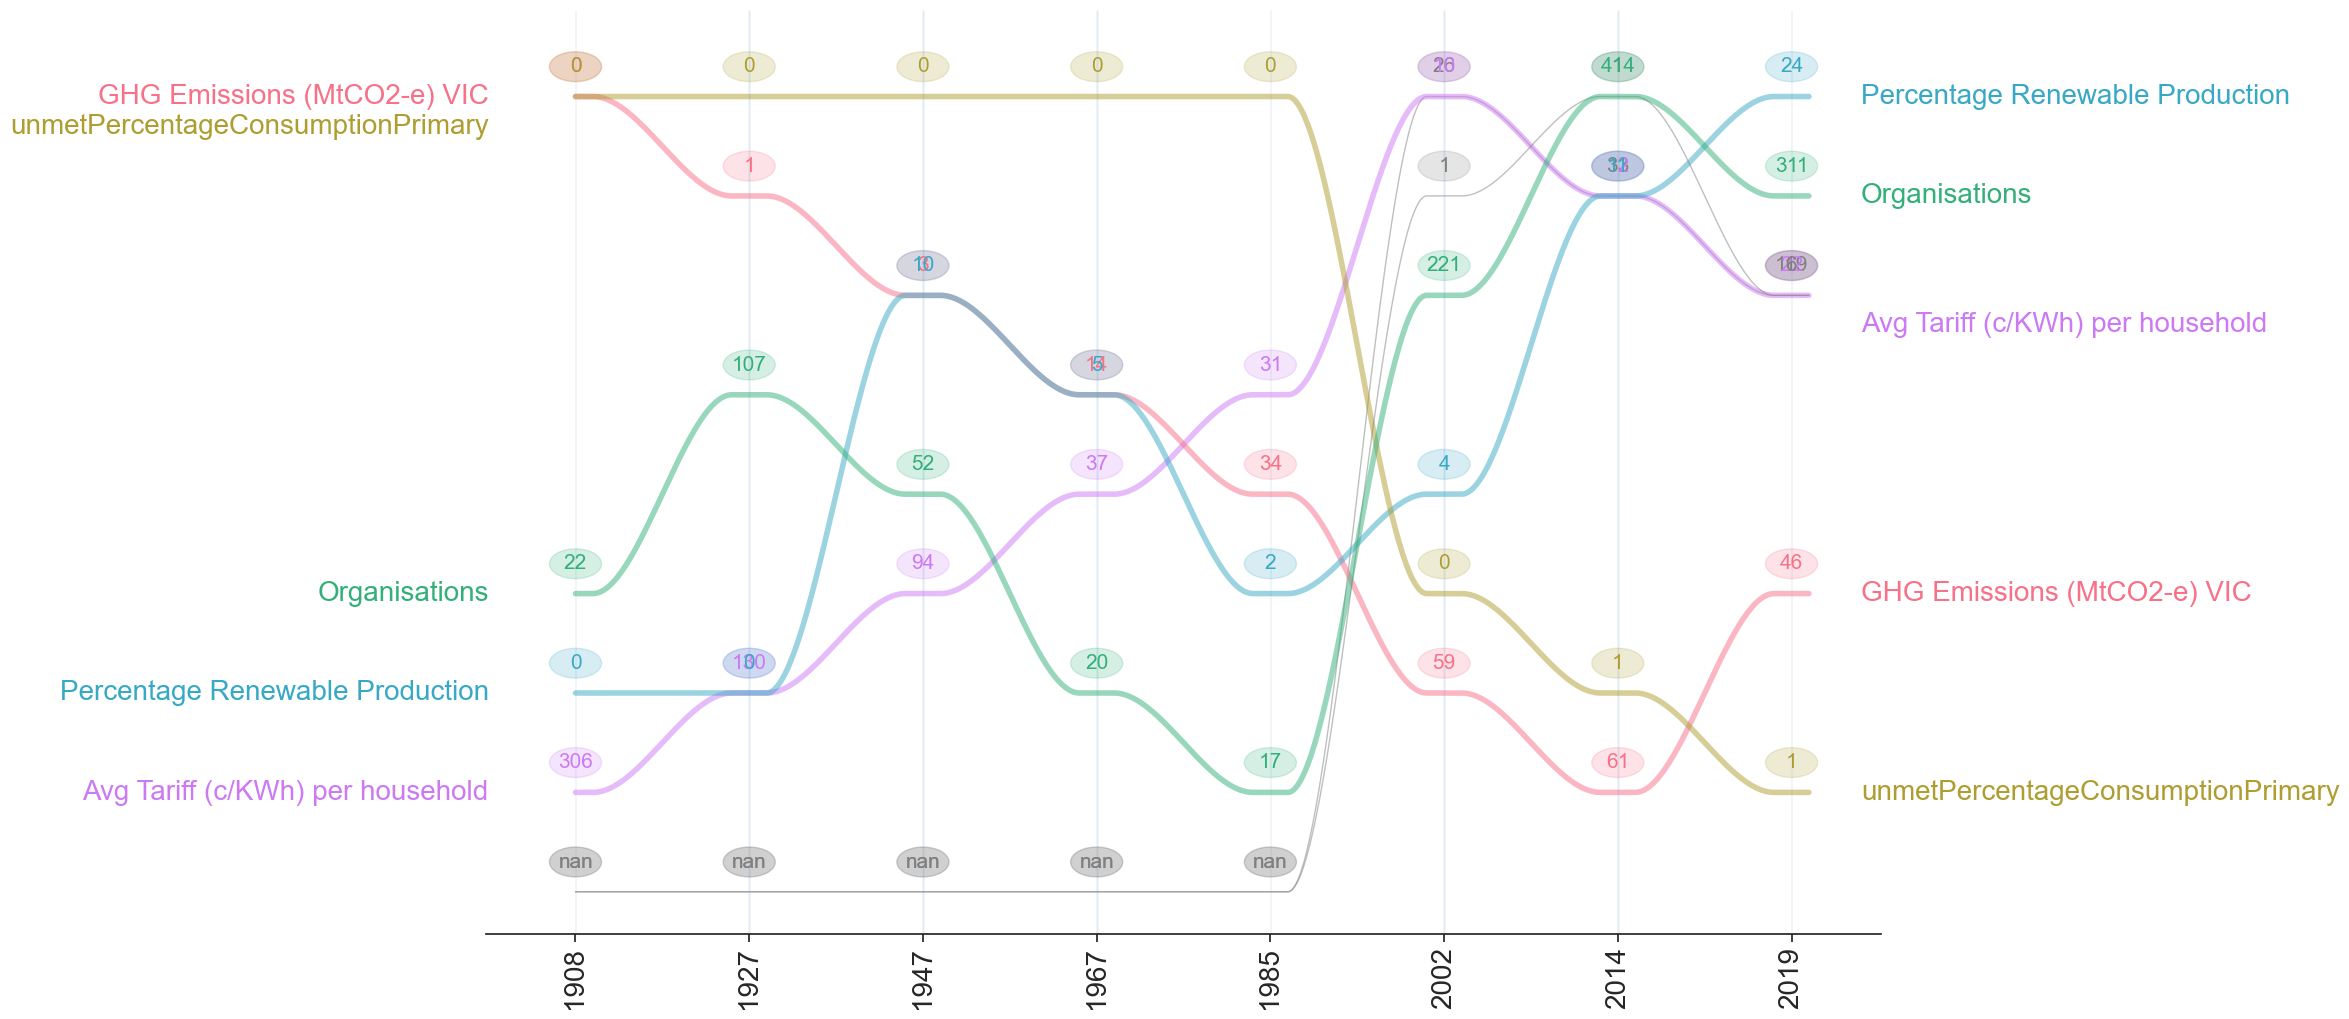

In [31]:
input_colors = defaultdict(lambda: "grey")
lw = defaultdict(lambda: 1)

data_rank_T = data_rank.T
top_inputs = data_rank_T.iloc[:, 0].dropna().sort_values().index

for i,c in enumerate(top_inputs):
    input_colors[c] = sns.color_palette("husl", n_colors=len(top_inputs))[i]
    lw[c] = 4



plt.figure(figsize=(18,12))
bumpsplot(data_rank_T, data.T, color_dict=input_colors, linewidth_dict=lw, labels=top_inputs)
plt.gca().get_yaxis().set_visible(False)

plt.xticks(np.arange(data_rank_T.shape[1]), ["{}".format(c) for c in data_rank_T.columns], rotation=90, fontsize=20)

for i,d in enumerate(data_rank_T.columns):
    #if i != 0 and i != len(data_rank_T.columns):
        plt.axvspan(i-0.005, i+0.005, zorder=0, alpha=0.15)

#plt.legend(loc="upper left")


sns.despine(left=True)

In [32]:
data_score = len(data_rank_T.columns) - data_rank_T
print(data_score.sum(axis=0))
data_score

1908    17.0
1927    19.0
1947    22.0
1967    19.0
1985    16.0
2002    31.0
2014    33.0
2019    30.0
dtype: float64


,1908,1927,1947,1967,1985,2002,2014,2019
Primary Wholesale ($/MWh),NaN,NaN,NaN,NaN,NaN,7.0,6.0,5.0
Avg Tariff (c/KWh) per household,0.0,1.0,2.0,3.0,4.0,7.0,6.0,5.0
GHG Emissions (MtCO2-e) VIC,7.0,6.0,5.0,4.0,3.0,1.0,0.0,2.0
Percentage Renewable Production,1.0,1.0,5.0,4.0,2.0,3.0,6.0,7.0
unmetPercentageConsumptionPrimary,7.0,7.0,7.0,7.0,7.0,2.0,1.0,0.0
Energy Vulnerability,NaN,NaN,NaN,NaN,NaN,6.0,7.0,5.0
Organisations,2.0,4.0,3.0,1.0,0.0,5.0,7.0,6.0


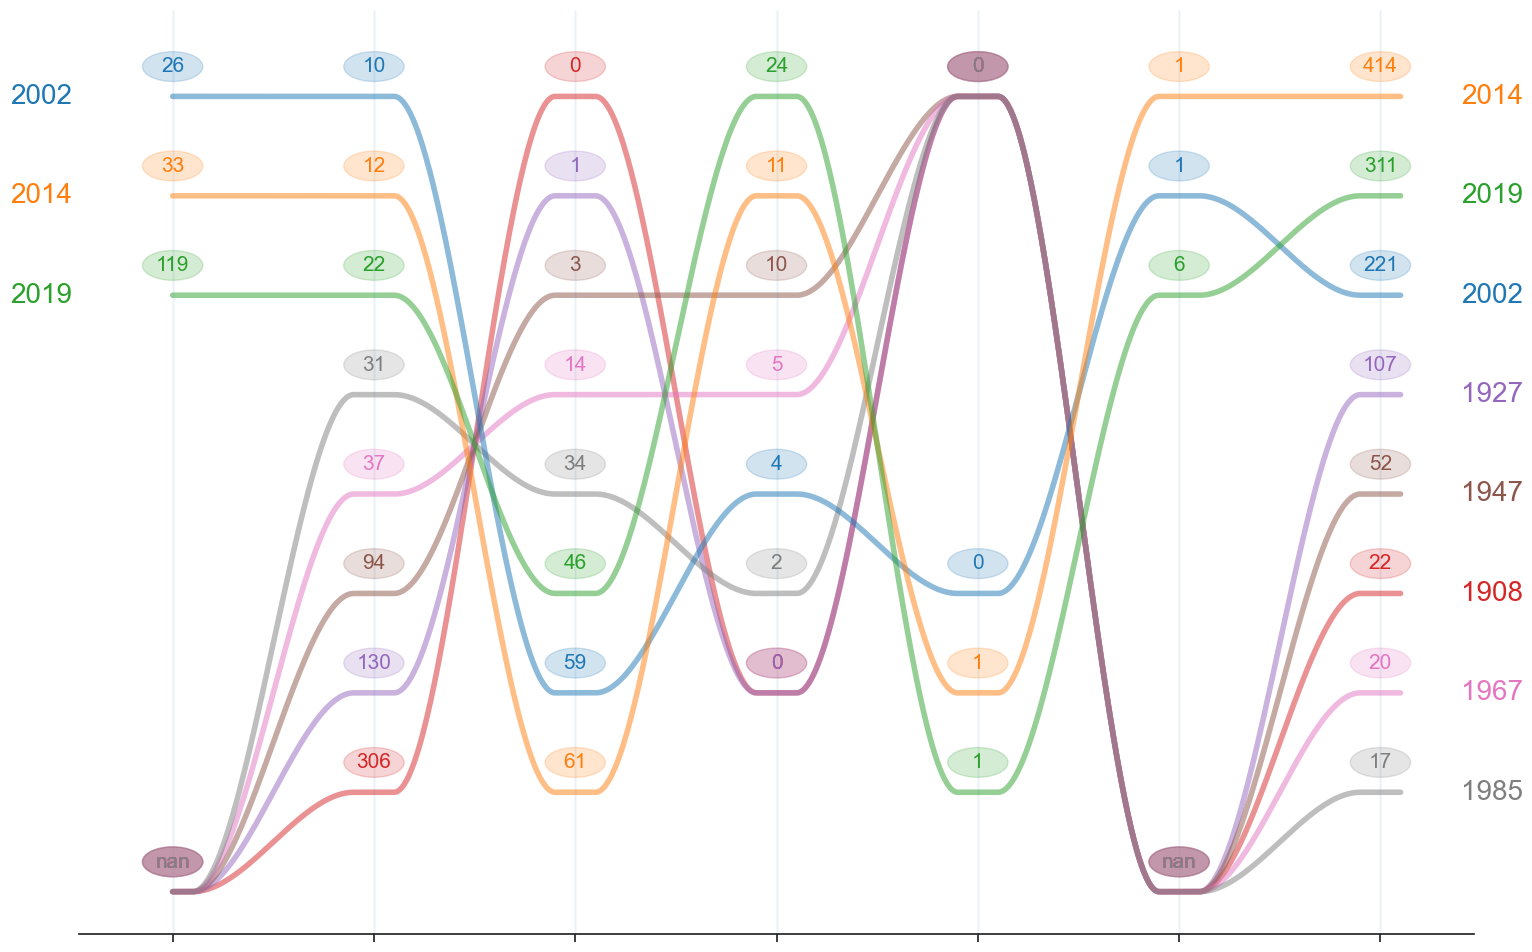

In [33]:
input_colors = defaultdict(lambda: "grey")
lw = defaultdict(lambda: 1)

#top_inputs = data_rank.iloc[:, 0].dropna().sort_values().index
top_inputs = data_rank.iloc[:, 0].sort_values().index

for i,c in enumerate(top_inputs):
    input_colors[c] = sns.color_palette("tab10", n_colors=len(top_inputs))[i]
    lw[c] = 4


plt.figure(figsize=(18,12))
bumpsplot(data_rank, data, color_dict=input_colors, linewidth_dict=lw, labels=top_inputs)
plt.gca().get_yaxis().set_visible(False)

plt.xticks(np.arange(data_rank.shape[1]), ["".format(c) for c in data_rank.columns], rotation=90, fontsize=20)

for i,d in enumerate(data_rank.columns):
    #if i != 0 and i != len(data_rank.columns)-1:
        plt.axvspan(i-0.005, i+0.005, zorder=0, alpha=0.1)

sns.despine(left=True)

# Wrapped Bar

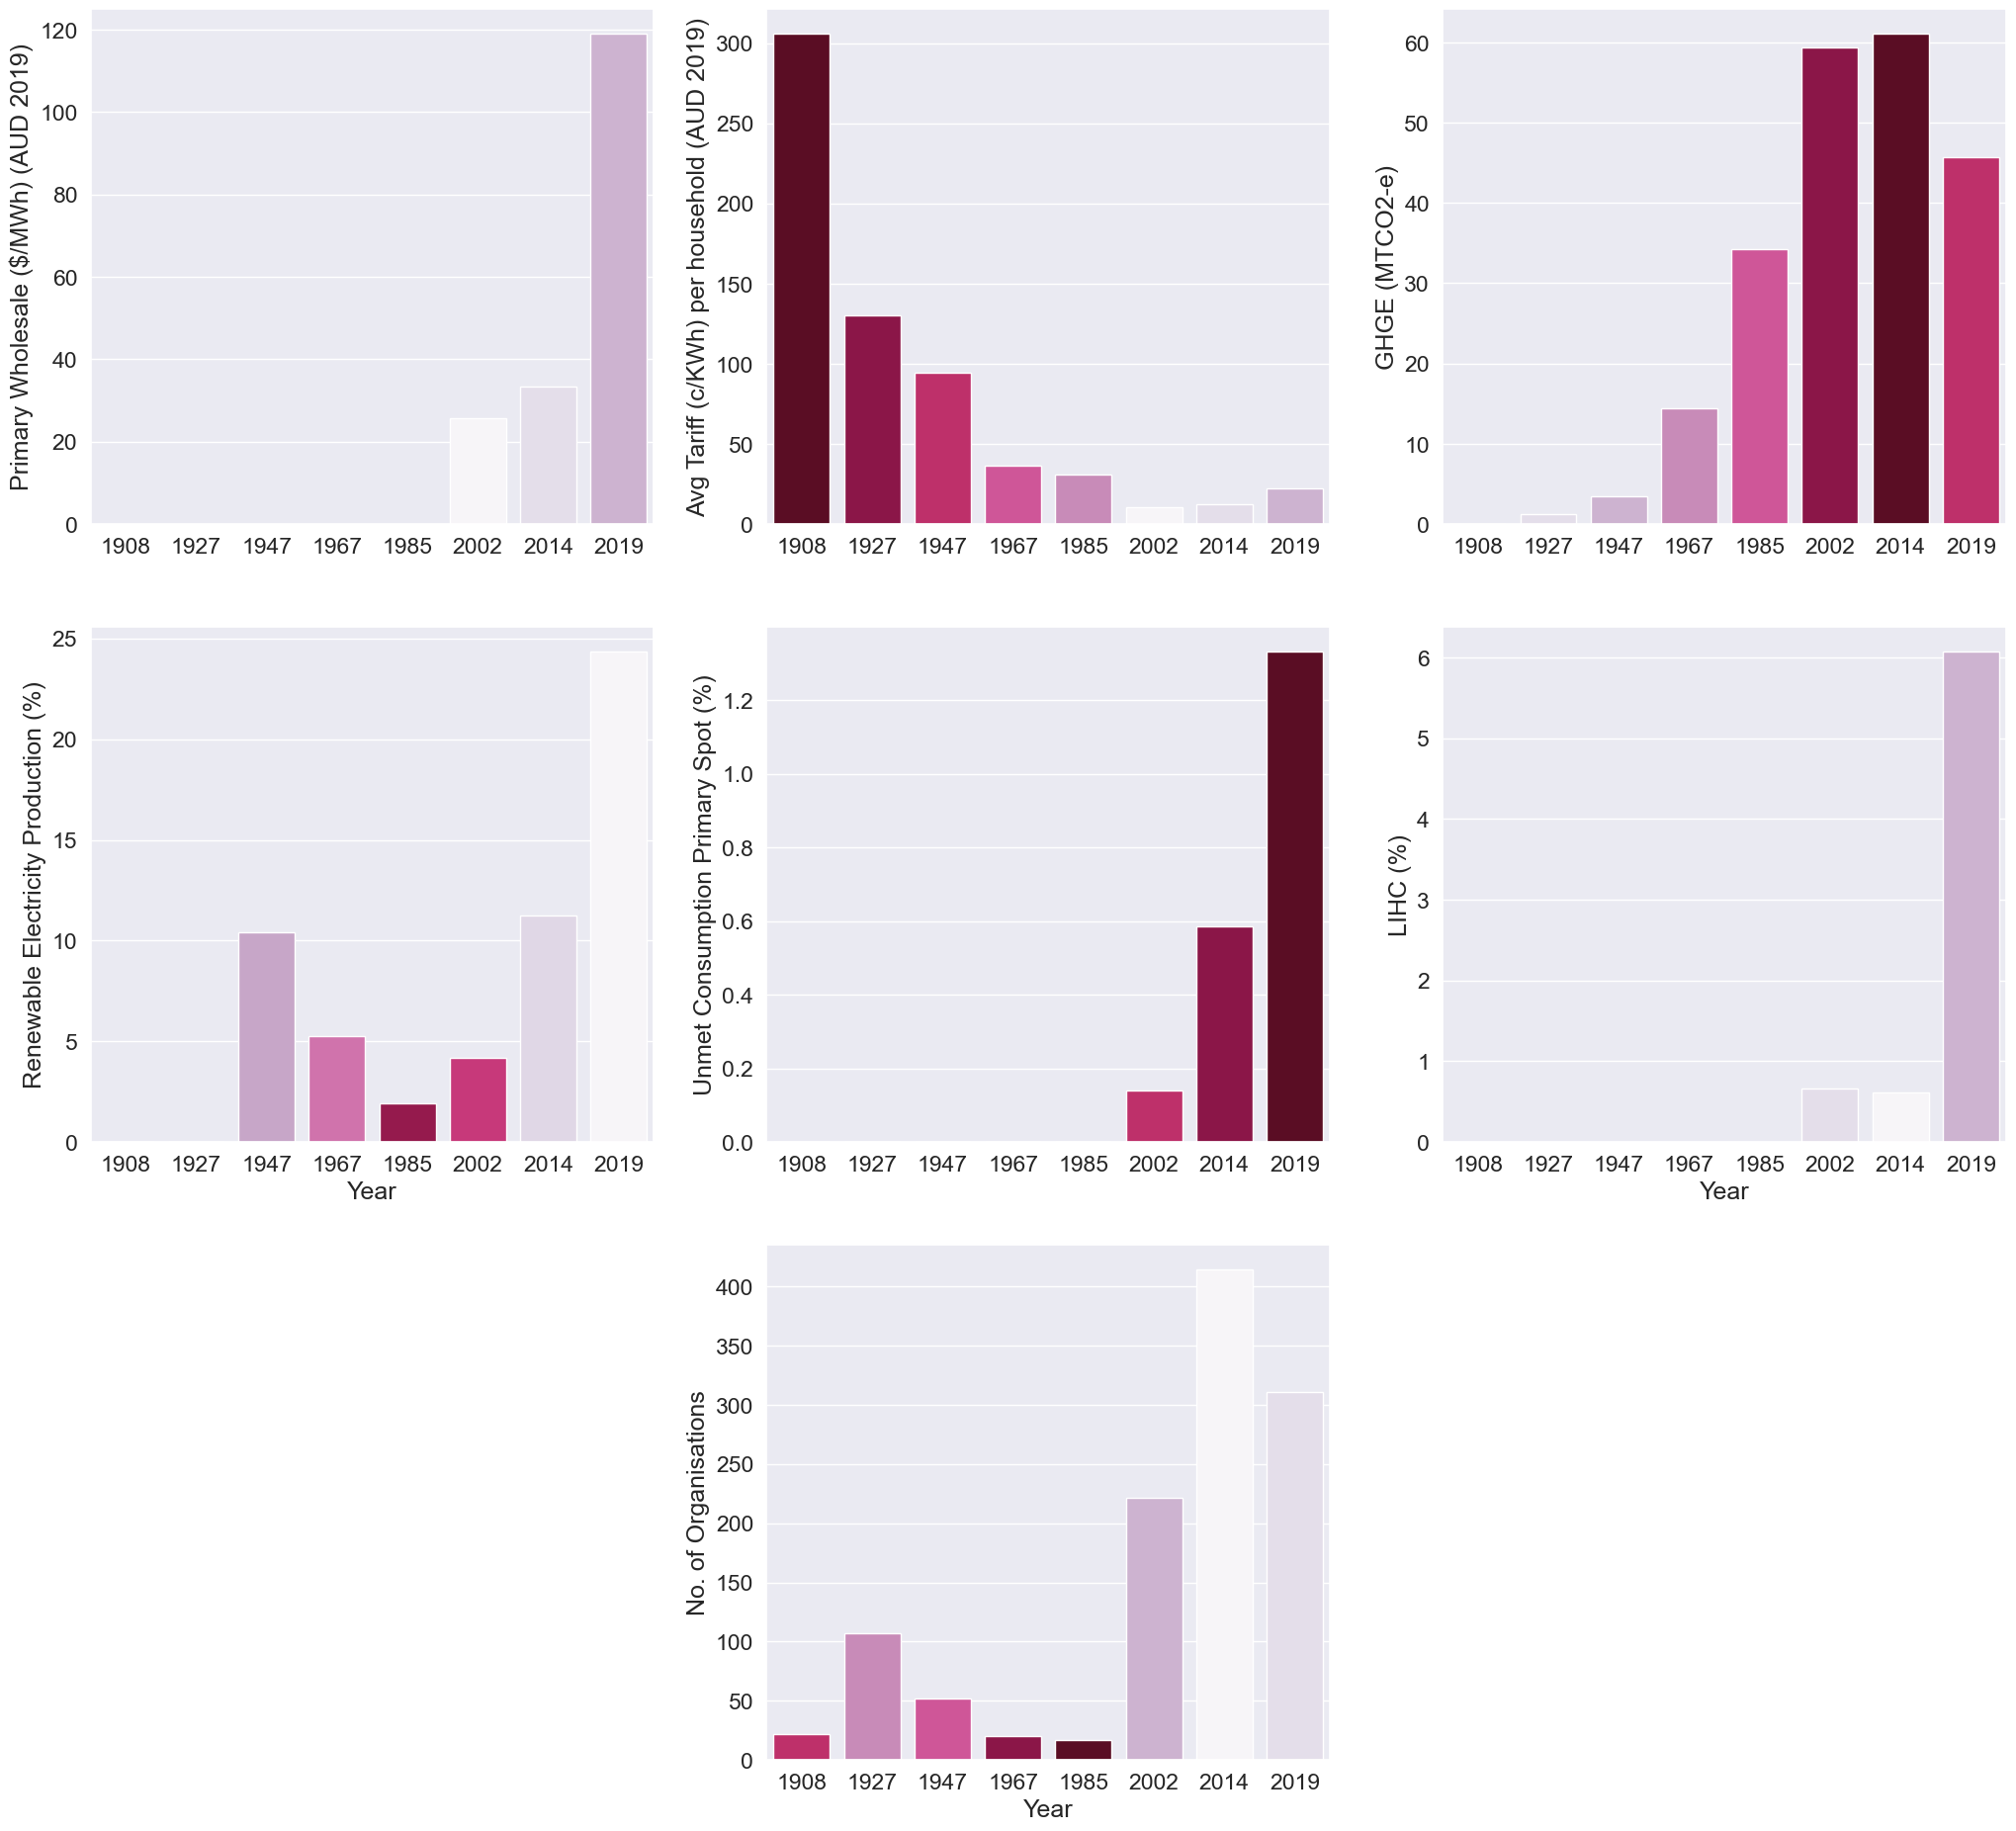

In [34]:
fig = plt.figure(figsize=(25, 23))

d_df = data.rename_axis('Time (Year)').reset_index().rename(columns={"Primary Wholesale ($/MWh)": "Wholesale ($/MWh)",
                     "Avg Tariff (c/KWh) per household": "Tariffs (c/KWh)" ,
                     "GHG Emissions (MtCO2-e) VIC": "GHGE (MtonCO_2)",
                     "Percentage Renewable Production": "Renewables (%)",
                     "unmetPercentageConsumptionPrimary": "Unmet Consumption (%)",
                     "Energy Vulnerability": "LIHC (% Households)",
                     "Organisations" : "Organisations (Number)"
                    })
r_df = data_rank.rename(columns={"Primary Wholesale ($/MWh)": r"Wholesale ($/MWh)",
                     "Avg Tariff (c/KWh) per household": "Tariffs (c/KWh)" ,
                     "GHG Emissions (MtCO2-e) VIC": "GHGE (MtonCO_2)",
                     "Percentage Renewable Production": "Renewables (%)",
                     "unmetPercentageConsumptionPrimary": "Unmet Consumption (%)",
                     "Energy Vulnerability": "LIHC (% Households)",
                     "Organisations" : "Organisations (Number)"
                    })

r_df['Wholesale ($/MWh)'] = r_df['Wholesale ($/MWh)'].fillna(8)
r_df['Unmet Consumption (%)'] = r_df['Unmet Consumption (%)'].fillna(8)
r_df['LIHC (% Households)'] = r_df['LIHC (% Households)'].fillna(8)
r_df = r_df.reset_index()

#pal_max = sns.color_palette("PuRd_r", len(d_df)+1)
#pal_min = sns.color_palette("PuRd_r", len(d_df)-5)

sns.set_theme(style="whitegrid")
sns.set(font_scale = 1.5)

ax1 = plt.subplot(331)
#ax1 = sns.barplot(x = 'Time (Year)', y = 'Wholesale ($/MWh)', data=d_df, palette=np.array(pal_max[::-1])[r_df['Wholesale ($/MWh)'].astype(int)])
ax1 = sns.barplot(x = 'Time (Year)', y = 'Wholesale ($/MWh)', data=d_df, hue=r_df['Wholesale ($/MWh)'], palette=("PuRd"), dodge=False)
ax1.set(xlabel="", ylabel = "Primary Wholesale ($/MWh) (AUD 2019)")
#ax1.yaxis.label.set_size(20)
ax1.legend().remove()

ax2 = plt.subplot(332)
ax2 = sns.barplot(x = 'Time (Year)', y = 'Tariffs (c/KWh)', data=d_df, hue = r_df['Tariffs (c/KWh)'], palette=("PuRd"), dodge=False)
ax2.set(xlabel="", ylabel = 'Avg Tariff (c/KWh) per household (AUD 2019)')
ax2.legend().remove()

ax3 = plt.subplot(3,3,3)
ax3 = sns.barplot(x = 'Time (Year)', y = 'GHGE (MtonCO_2)', data=d_df, hue = r_df['GHGE (MtonCO_2)'],palette=("PuRd"), dodge=False )
ax3.set(xlabel="", ylabel = "GHGE (MTCO2-e)")
ax3.legend().remove()

ax4 = plt.subplot(3,3,4)
ax4 = sns.barplot(x = 'Time (Year)', y = 'Renewables (%)', data=d_df, hue = r_df['Renewables (%)'], palette=("PuRd"), dodge=False)
ax4.set(xlabel="Year", ylabel = "Renewable Electricity Production (%)")
ax4.legend().remove()

ax5 = plt.subplot(3,3,5)
ax5 = sns.barplot(x = 'Time (Year)', y = 'Unmet Consumption (%)', data=d_df, hue = r_df['Unmet Consumption (%)'], palette=("PuRd"), dodge=False)
ax5.set(xlabel="", ylabel = "Unmet Consumption Primary Spot (%)")
ax5.legend().remove()

ax6 = plt.subplot(3,3,6)
ax6 = sns.barplot(x = 'Time (Year)', y = 'LIHC (% Households)', data=d_df, hue= r_df['LIHC (% Households)'], palette=("PuRd"), dodge=False)
ax6.set(xlabel="Year", ylabel = "LIHC (%)")
ax6.legend().remove()

ax7 = plt.subplot(3,3,8)
ax7= sns.barplot(x = 'Time (Year)', y =  'Organisations (Number)', data=d_df, hue=r_df['Organisations (Number)'], palette=("PuRd"), dodge=False)
ax7.set(xlabel="Year", ylabel = "No. of Organisations")

ax7.legend().remove()

# plt.title('Wholesale')
# sns.barplot(data = d_df, x='Time (Year)', y = '$/MWh')


# Categorical plots

In [35]:
# Plot
# g = sns.catplot(d_df.index, col=d_df[:0], col_wrap=4, data=d_df,
#                 kind="count", height=3.5, aspect=.8, palette='tab20')

#fig.suptitle('sf')
plt.show()